# Malaria

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls "/content/drive/MyDrive/malaria/data" #Comprobar el acceso a la de carpeta Drive
!cp "/content/drive/MyDrive/malaria/data/Malaria Data.zip" "/content/dataset.zip" #Crear copia del doc dentro del almacenamiento temporal de la máquina virtual de Colab.
!ls -lath /content/

Mounted at /content/drive
'Malaria Data.zip'
total 337M
-rw------- 1 root root 336M Jun 10 13:00 dataset.zip
drwxr-xr-x 1 root root 4.0K Jun 10 13:00 .
drwx------ 5 root root 4.0K Jun 10 13:00 drive
drwxr-xr-x 1 root root 4.0K Jun 10 12:54 ..
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data
drwxr-xr-x 4 root root 4.0K Jun  4 13:39 .config


In [ ]:
# Capture evita que se muestre el resultado en la consola (+ de 5.000 líneas)
%%capture
!unzip "/content/dataset.zip" -d "/content/dataset" #Descomprimir el archivo

In [ ]:
import os
import cv2

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models

I0000 00:00:1781097897.744378   69603 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 3. Implementación de una CNN para clasificar células con malaria

En esta actividad se creó una red neuronal convolucional para clasificar imágenes de células en dos grupos - infectadas por malaria y sanas. Para ello se prepararon las imágenes, se entrenó una CNN y después se evaluaron los resultados.

## A. Preparación del dataset y preprocesamiento

Primero se cargaron las imágenes con OpenCV. Todas las imágenes se redimensionaron a 100 x 100 píxeles, para que tuvieran el mismo tamaño. También se normalizaron los valores de los píxeles dividiendo entre 255, para que estuvieran entre 0 y 1.

In [ ]:
cell_images_dir = "Malaria"
target_image_size = 100

cell_images = []
infection_labels = []

cell_classes = ["Uninfected", "Parasitized"]

for infection_label, cell_class_name in enumerate(cell_classes):
    cell_class_dir = os.path.join(cell_images_dir, cell_class_name)

    for image_file_name in os.listdir(cell_class_dir):
        image_file_path = os.path.join(cell_class_dir, image_file_name)

        cell_image = cv2.imread(image_file_path)

        if cell_image is not None:
            cell_image = cv2.resize(cell_image, (target_image_size, target_image_size))
            cell_image = cv2.cvtColor(cell_image, cv2.COLOR_BGR2RGB)
            cell_image = cell_image.astype("float32") / 255.0

            cell_images.append(cell_image)
            infection_labels.append(infection_label)

image_data = np.array(cell_images)
label_data = np.array(infection_labels)

print("images shape:", image_data.shape)
print("labels shape:", label_data.shape)

images shape: (27558, 100, 100, 3)
labels shape: (27558,)


Después se dividieron los datos en tres partes: **entrenamiento**, **validación** y **prueba**.

In [ ]:
train_images, temp_images, train_labels, temp_labels = train_test_split(
    image_data,
    label_data,
    test_size=0.30,
    random_state=10,
    stratify=label_data
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images,
    temp_labels,
    test_size=0.50,
    random_state=10,
    stratify=temp_labels
)

print("train:", train_images.shape)
print("validation:", val_images.shape)
print("test:", test_images.shape)

train: (19290, 100, 100, 3)
validation: (4134, 100, 100, 3)
test: (4134, 100, 100, 3)


Se han usado 3 canales, porque las imágenes están en color RGB. Esto puede ayudar al modelo a reconocer mejor las diferencias visuales entre células sanas e infectadas.

## B. Diseño de la red neuronal convolucional

Se creó una CNN con varias capas convolucionales, capas de pooling y capas Dropout. Las capas convolucionales sirven para detectar patrones en las imágenes, como bordes, formas o texturas. Las capas de pooling reducen el tamaño de la información y las capas Dropout ayudan a evitar el sobreajuste.

En esta versión se ha dejado una optimización algo mejorable, porque se usa un learning rate relativamente alto y solo 15 épocas. Esto puede hacer que el modelo aprenda de forma menos estable o que no alcance el mejor resultado posible.


In [ ]:
malaria_model = models.Sequential()

malaria_model.add(layers.Conv2D(16, (5, 5), activation="relu", input_shape=(100, 100, 3)))
malaria_model.add(layers.MaxPooling2D((2, 2)))

malaria_model.add(layers.Conv2D(32, (3, 3), activation="relu"))
malaria_model.add(layers.MaxPooling2D((2, 2)))
malaria_model.add(layers.Dropout(0.2))

malaria_model.add(layers.Conv2D(64, (3, 3), activation="relu"))
malaria_model.add(layers.MaxPooling2D((2, 2)))
malaria_model.add(layers.Dropout(0.3))

malaria_model.add(layers.Flatten())

malaria_model.add(layers.Dense(64, activation="relu"))
malaria_model.add(layers.Dropout(0.4))

malaria_model.add(layers.Dense(1, activation="sigmoid"))

malaria_model.summary()

adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)

malaria_model.compile(
    optimizer=adam_optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/home/porvik/Downloads/Malaria/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781097928.074518   69603 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8397 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:07:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 434,081 (1.66 MB)

 Trainable params: 434,081 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

La función de activación usada en la última capa es sigmoid, porque el problema es de clasificación binaria. Solo hay dos clases - célula sana y célula infectada. La función sigmoid devuelve un valor entre 0 y 1, que puede interpretarse como la probabilidad de que la imagen pertenezca a la clase infectada.

La función de pérdida usada es binary_crossentropy, porque es la más adecuada para problemas con dos clases y una salida sigmoide. Esta función compara la clase real con la probabilidad predicha por el modelo y penaliza las predicciones incorrectas.

Se han escogido 3 canales, correspondientes a imágenes RGB. Se mantiene el color porque las imágenes microscópicas pueden tener información útil en la tinción, la textura y el aspecto de las células. Esta información puede ayudar al modelo a diferenciar mejor entre células sanas e infectadas.

## Entrenamiento

In [ ]:
training_history = malaria_model.fit(
    train_images,
    train_labels,
    epochs=15,
    batch_size=64,
    validation_data=(val_images, val_labels)
)

W0000 00:00:1781097930.838331   69603 cpu_allocator_impl.cc:82] Allocation of 2314800000 exceeds 10% of free system memory.
W0000 00:00:1781097933.907166   69603 cpu_allocator_impl.cc:82] Allocation of 2314800000 exceeds 10% of free system memory.


Epoch 1/15


I0000 00:00:1781097935.861474   71105 service.cc:153] XLA service 0x7f8f00034c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781097935.861491   71105 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3080, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.1)
I0000 00:00:1781097935.898790   71105 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781097936.104514   71105 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1781097936.169560   71105 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2290__.38


 30/302 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4891 - loss: 0.7982

I0000 00:00:1781097940.484469   71105 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


295/302 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5344 - loss: 0.7073

I0000 00:00:1781097942.194219   71104 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2290__.38


302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5350 - loss: 0.7068

W0000 00:00:1781097946.013073   69603 cpu_allocator_impl.cc:82] Allocation of 496080000 exceeds 10% of free system memory.
W0000 00:00:1781097946.486037   69603 cpu_allocator_impl.cc:82] Allocation of 496080000 exceeds 10% of free system memory.


302/302 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.5605 - loss: 0.6858 - val_accuracy: 0.6009 - val_loss: 0.6764
Epoch 2/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6245 - loss: 0.6548 - val_accuracy: 0.6401 - val_loss: 0.6368
Epoch 3/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8053 - loss: 0.4065 - val_accuracy: 0.9434 - val_loss: 0.1758
Epoch 4/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9468 - loss: 0.1756 - val_accuracy: 0.9470 - val_loss: 0.1761
Epoch 5/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9501 - loss: 0.1597 - val_accuracy: 0.9509 - val_loss: 0.1518
Epoch 6/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9533 - loss: 0.1468 - val_accuracy: 0.9502 - val_loss: 0.1699
Epoch 7/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9548 - loss: 0.1471 - val_accuracy: 0.9538 - val_loss: 0.1522
Epoch 8/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9535 - loss: 0.1505 - val_accuracy: 0.9538 - va

El modelo funciona, pero no está totalmente optimizado. Podría mejorar con un learning rate menor, más épocas o técnicas de data augmentation.

## C. Gráficos y evaluación
Se representó la evolución de la pérdida y la precisión.

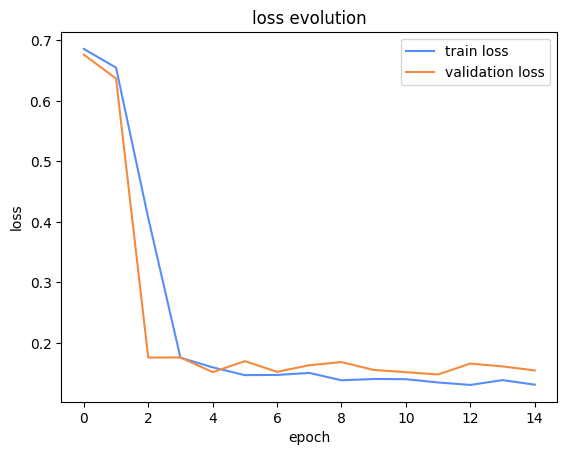

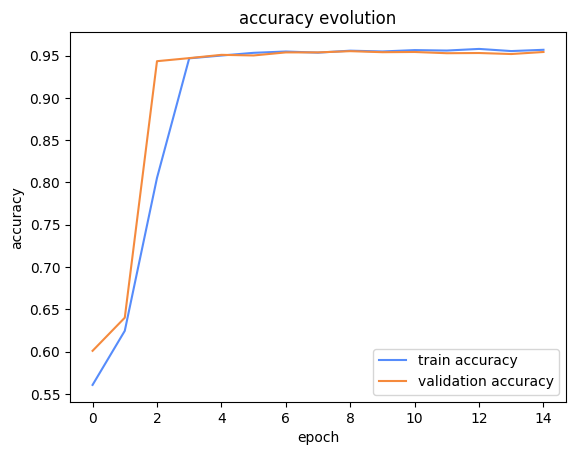

In [ ]:
plt.plot(training_history.history["loss"], label="train loss")
plt.plot(training_history.history["val_loss"], label="validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("loss evolution")
plt.legend()
plt.show()

plt.plot(training_history.history["accuracy"], label="train accuracy")
plt.plot(training_history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("accuracy evolution")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = malaria_model.evaluate(test_images, test_labels)

print("test loss:", test_loss)
print("test accuracy:", test_accuracy)

W0000 00:00:1781097972.343414   69603 cpu_allocator_impl.cc:82] Allocation of 496080000 exceeds 10% of free system memory.


130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9482 - loss: 0.1484
test loss: 0.14838798344135284
test accuracy: 0.9482341408729553


También se generó una confusion matrix.

130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


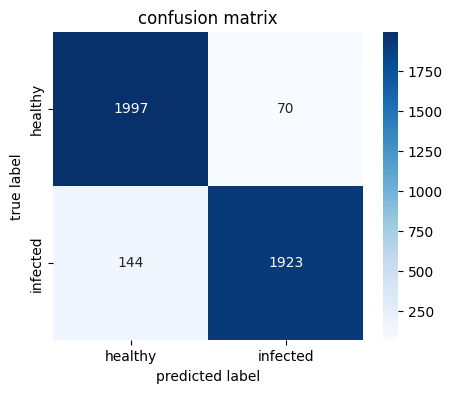

              precision    recall  f1-score   support

     healthy       0.93      0.97      0.95      2067
    infected       0.96      0.93      0.95      2067

    accuracy                           0.95      4134
   macro avg       0.95      0.95      0.95      4134
weighted avg       0.95      0.95      0.95      4134



In [ ]:
predicted_probabilities = malaria_model.predict(test_images)
predicted_labels = (predicted_probabilities >= 0.5).astype(int).ravel()

confusion_matrix_values = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix_values,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["healthy", "infected"],
    yticklabels=["healthy", "infected"]
)

plt.xlabel("predicted label")
plt.ylabel("true label")
plt.title("confusion matrix")
plt.show()

print(classification_report(
    test_labels,
    predicted_labels,
    target_names=["healthy", "infected"]
))

Por último, se muestran ejemplos de predicciones correctas e incorrectas.

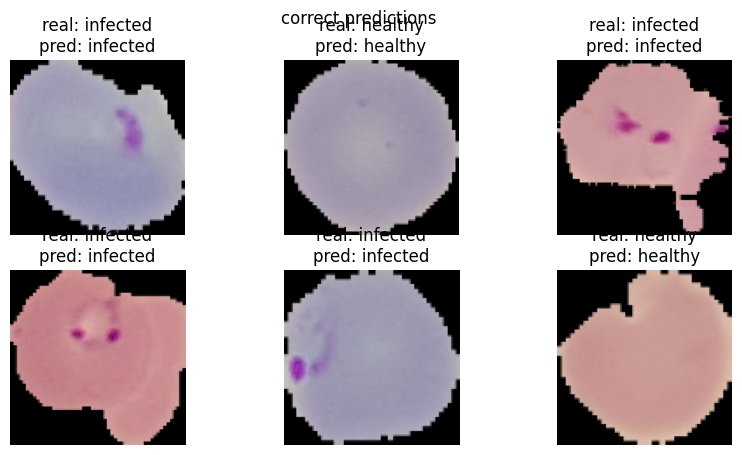

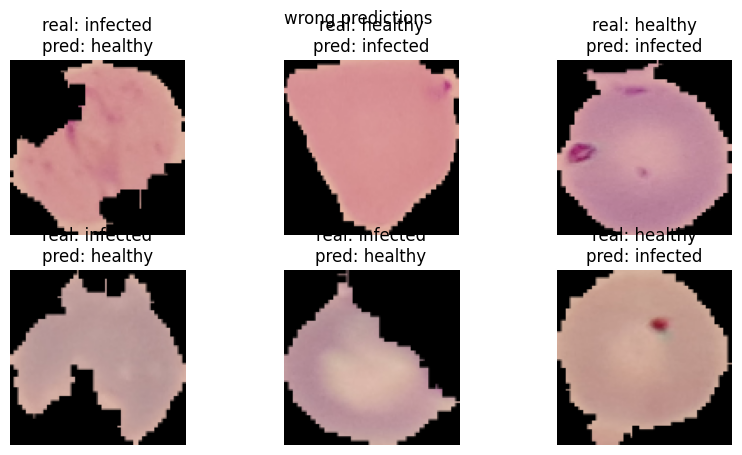

In [ ]:
class_names = ["healthy", "infected"]

correct_prediction_indices = np.where(predicted_labels == test_labels)[0]
wrong_prediction_indices = np.where(predicted_labels != test_labels)[0]

plt.figure(figsize=(10, 5))

for subplot_index, image_index in enumerate(correct_prediction_indices[:6]):
    plt.subplot(2, 3, subplot_index + 1)
    plt.imshow(test_images[image_index])
    plt.title(
        "real: " + class_names[test_labels[image_index]] +
        "\npred: " + class_names[predicted_labels[image_index]]
    )
    plt.axis("off")

plt.suptitle("correct predictions")
plt.show()

plt.figure(figsize=(10, 5))

for subplot_index, image_index in enumerate(wrong_prediction_indices[:6]):
    plt.subplot(2, 3, subplot_index + 1)
    plt.imshow(test_images[image_index])
    plt.title(
        "real: " + class_names[test_labels[image_index]] +
        "\npred: " + class_names[predicted_labels[image_index]]
    )
    plt.axis("off")

plt.suptitle("wrong predictions")
plt.show()

Los errores pueden aparecer porque algunas imágenes tienen poca calidad, porque las células están cortadas o porque algunas células infectadas se parecen mucho a las sanas.